# Week 3: Final Integration - Multi-Layer Probe + CCE Spike Detection

## The Complete Solution

**What we learned:**
1. ✅ **Multi-layer probing works!** (100% accuracy)
2. ✅ **Best layers: [8, 16, 31]** (syntax + semantics + pre-output)
3. ✅ **Linear probe is sufficient** (information is linearly separable)
4. ✅ **Ambiguous tokens work:** "get", "table" correctly classified by context

**This notebook:**
- Loads the trained multi-layer probe
- At each generation step:
  1. Extracts hidden states from layers [8, 16, 31]
  2. Probe predicts mode (code vs language)
  3. Dynamically classifies tokens based on mode
  4. Computes proper CCE formula
- Scans 20 tokens for **maximum CCE spike**
- Tests hypothesis: Missing context → +CCE, Language choice → -CCE

---

In [1]:
# Cell 1: Install
!pip install -q transformers torch accelerate scipy scikit-learn pandas matplotlib seaborn

In [2]:
# Cell 2: Imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List
from transformers import AutoTokenizer, AutoModelForCausalLM
from scipy.stats import entropy as scipy_entropy, ttest_ind
from sklearn.linear_model import LogisticRegression
from tqdm.notebook import tqdm
import pickle

np.random.seed(42)
torch.manual_seed(42)
print("✅ Imports")

✅ Imports


In [3]:
# Cell 3: Load Model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True
)
model.eval()
vocab_size = len(tokenizer)

print(f"✅ Model loaded")
print(f"Vocabulary size: {vocab_size:,}")

Loading codellama/CodeLlama-7b-Instruct-hf...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

✅ Model loaded
Vocabulary size: 32,016


## Load Trained Probe

In [4]:
# Cell 4: Load probe

# If you have the saved probe, uncomment this:
# with open('best_multi_layer_probe.pkl', 'rb') as f:
#     probe_config = pickle.load(f)
#     probe = probe_config['probe']
#     SELECTED_LAYERS = probe_config['selected_layers']

# Otherwise, we'll train a quick probe here
print("Training multi-layer probe...")

SELECTED_LAYERS = [8, 16, 31]  # Best combination from ablation

# Quick training data
CODE_PROMPTS = [
    "def calculate_sum(a, b):", "import pandas as pd", "for i in range(10):",
    "class UserManager:", "return {", "df = pd.read_csv(",
    "const data = await", "function handleClick() {", "SELECT * FROM users",
    "@app.get('/users')", "model.fit(X, y)", "git commit -m",
]

LANG_PROMPTS = [
    "The quick brown fox", "Explain the theory of", "Once upon a time",
    "I need help with", "The main difference is", "For example,",
    "It is important to", "According to the study,", "On the other hand,",
    "The meaning of life", "We should consider", "Many experts agree",
]

def get_multi_layer_state(prompt: str, layers: List[int]) -> np.ndarray:
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
    states = [
        outputs.hidden_states[layer_idx + 1][:, -1, :].cpu().numpy()[0]
        for layer_idx in layers
    ]
    return np.concatenate(states)

X_train = []
for prompt in CODE_PROMPTS:
    X_train.append(get_multi_layer_state(prompt, SELECTED_LAYERS))
for prompt in LANG_PROMPTS:
    X_train.append(get_multi_layer_state(prompt, SELECTED_LAYERS))

X_train = np.array(X_train)
y_train = np.array([1] * len(CODE_PROMPTS) + [0] * len(LANG_PROMPTS))

probe = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
probe.fit(X_train, y_train)

print(f"✅ Probe trained")
print(f"   Layers: {SELECTED_LAYERS}")
print(f"   Accuracy: {probe.score(X_train, y_train):.1%}")

Training multi-layer probe...
✅ Probe trained
   Layers: [8, 16, 31]
   Accuracy: 100.0%


## Helper Functions

In [5]:
# Cell 5: Math helpers

def softmax(logits: np.ndarray) -> np.ndarray:
    logits_stable = logits - np.max(logits)
    exp_logits = np.exp(logits_stable)
    return exp_logits / np.sum(exp_logits)

def entropy_from_probs(probs: np.ndarray) -> float:
    if len(probs) == 0 or np.sum(probs) == 0:
        return 0.0
    norm_probs = probs / np.sum(probs)
    return float(scipy_entropy(norm_probs, base=2))

print("✅ Math helpers")

✅ Math helpers


In [6]:
# Cell 6: Token classification

PURE_CODE_TOKENS = {
    'def', 'class', 'import', 'from', 'return', 'yield',
    'function', 'const', 'let', 'var', 'export', 'require',
    '{', '}', '(', ')', '[', ']', ';',
}

PURE_LANGUAGE_TOKENS = {
    'the', 'a', 'an', 'is', 'are', 'was', 'were',
    'what', 'how', 'why', 'when', 'where',
}

STRUCTURAL_TOKENS = {
    '\n', '\r', '\t', '    ', '  ',
    ',', '.', ':', '+', '-', '*', '/', '=', '<', '>',
}

def classify_token_dynamic(token: str, context_score: float) -> str:
    """
    Classify token based on probe's context score.

    context_score > 0 → code mode
    context_score < 0 → language mode
    """
    token_clean = token.strip().lower()

    if token in STRUCTURAL_TOKENS or token_clean in STRUCTURAL_TOKENS:
        return 'other'
    if token_clean in PURE_CODE_TOKENS:
        return 'code'
    if token_clean in PURE_LANGUAGE_TOKENS:
        return 'language'

    # AMBIGUOUS: Use probe!
    if context_score > 0:  # Code mode
        return 'code'
    else:  # Language mode
        return 'language'

print("✅ Dynamic token classifier")

✅ Dynamic token classifier


In [7]:
# Cell 7: CCE computation

def compute_cce_proper(logits: np.ndarray, context_score: float) -> Dict:
    """
    Compute PROPER mass-weighted CCE.
    CCE = (P_code × H_code) - (P_lang × H_lang)
    """
    probs = softmax(logits)

    # Classify all tokens dynamically
    vocab_classifications = {}
    for token_id in range(len(logits)):
        token_str = tokenizer.decode([token_id])
        vocab_classifications[token_id] = classify_token_dynamic(token_str, context_score)

    code_indices = [i for i in range(len(logits)) if vocab_classifications[i] == 'code']
    lang_indices = [i for i in range(len(logits)) if vocab_classifications[i] == 'language']
    other_indices = [i for i in range(len(logits)) if vocab_classifications[i] == 'other']

    P_code = np.sum(probs[code_indices]) if code_indices else 0.0
    P_lang = np.sum(probs[lang_indices]) if lang_indices else 0.0
    P_other = np.sum(probs[other_indices]) if other_indices else 0.0

    H_code = entropy_from_probs(probs[code_indices])
    H_lang = entropy_from_probs(probs[lang_indices])

    CCE = (P_code * H_code) - (P_lang * H_lang)

    return {
        'cce': float(CCE),
        'p_code': float(P_code),
        'p_lang': float(P_lang),
        'p_other': float(P_other),
        'h_code': float(H_code),
        'h_lang': float(H_lang),
    }

print("✅ PROPER CCE function")

✅ PROPER CCE function


## Test Examples

In [8]:
# Cell 8: Test examples

TEST_EXAMPLES = [
    # Missing context (code uncertainty) - obscure APIs
    {'id': 'code_1', 'type': 'missing_context',
     'prompt': 'Using the PySolarWinds wrapper, connect to the Orion API and query node status. Show code.'},
    {'id': 'code_2', 'type': 'missing_context',
     'prompt': 'Write a function using MyCorpAuth library to validate JWT tokens.'},
    {'id': 'code_3', 'type': 'missing_context',
     'prompt': 'In PyTorch 0.2, use the Variable wrapper for autograd. Show exact import.'},
    {'id': 'code_4', 'type': 'missing_context',
     'prompt': 'Using QuantumDjango, create a quantum-entangled database model.'},
    {'id': 'code_5', 'type': 'missing_context',
     'prompt': 'Write code using Netlify Edge Functions beta API for GraphQL subscriptions.'},

    # Language choice (language uncertainty) - pure text
    {'id': 'lang_1', 'type': 'language_choice',
     'prompt': 'Write a poem about a compiler optimizing code.'},
    {'id': 'lang_2', 'type': 'language_choice',
     'prompt': 'Explain the philosophical difference between OOP and functional programming.'},
    {'id': 'lang_3', 'type': 'language_choice',
     'prompt': 'Describe a good software engineer using nature metaphors.'},
    {'id': 'lang_4', 'type': 'language_choice',
     'prompt': 'Write a story where variables rebel against their programmer.'},
    {'id': 'lang_5', 'type': 'language_choice',
     'prompt': 'Explain recursion to a five-year-old child.'},
]

print(f"✅ {len(TEST_EXAMPLES)} test examples ready")

✅ 10 test examples ready


## Multi-Layer Probe + Spike Detection (THE FINAL SOLUTION)

In [9]:
# Cell 9: Multi-layer probe spike detection

def run_multi_layer_spike_detection(example: Dict, probe, probe_layers: List[int]) -> Dict:
    """
    FINAL WEEK 3 SOLUTION:

    At each generation step:
    1. Extract hidden states from layers [8, 16, 31]
    2. Probe predicts mode (code vs language)
    3. Dynamically classify tokens based on mode
    4. Compute PROPER CCE
    5. Find maximum spike across 20 tokens
    """
    prompt = example['prompt']
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    # Generate 20 tokens with hidden states
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=20,
            return_dict_in_generate=True,
            output_scores=True,
            output_hidden_states=True,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(outputs.sequences[0], skip_special_tokens=True)
    new_text = generated_text[len(prompt):]

    # Scan for maximum CCE spike
    max_cce = -999.0
    spike_info = {}
    cce_trace = []

    generated_ids = outputs.sequences[0][len(inputs.input_ids[0]):]

    for i in range(len(outputs.scores)):
        # Step 1: Extract multi-layer hidden state at THIS step
        states = [
            outputs.hidden_states[i][layer_idx + 1][0, -1, :].cpu().numpy()
            for layer_idx in probe_layers
        ]
        step_hidden = np.concatenate(states)

        # Step 2: Probe detects mode
        context_score = probe.decision_function([step_hidden])[0]
        # context_score > 0 → code mode
        # context_score < 0 → language mode

        # Step 3 & 4: Compute CCE with dynamic classification
        logits = outputs.scores[i][0].cpu().numpy()
        result = compute_cce_proper(logits, context_score)

        # Get token
        token_id = generated_ids[i] if i < len(generated_ids) else -1
        token_str = tokenizer.decode([token_id])

        cce_trace.append({
            'step': i,
            'token': token_str,
            'cce': result['cce'],
            'context_score': context_score,
            'p_code': result['p_code'],
            'p_lang': result['p_lang'],
            'p_other': result['p_other'],
        })

        # Step 5: Track maximum
        if result['cce'] > max_cce:
            max_cce = result['cce']
            spike_info = cce_trace[-1].copy()

    return {
        'id': example['id'],
        'type': example['type'],
        'prompt': prompt,
        'generated_text': new_text,
        'contrastive_entropy': max_cce,
        'spike_token': spike_info.get('token', ''),
        'spike_step': spike_info.get('step', 0),
        'spike_context_score': spike_info.get('context_score', 0),
        'code_prob_mass': spike_info.get('p_code', 0),
        'lang_prob_mass': spike_info.get('p_lang', 0),
        'other_prob_mass': spike_info.get('p_other', 0),
        'cce_trace': cce_trace,
    }

print("✅ Multi-layer spike detection ready")

✅ Multi-layer spike detection ready


In [10]:
# Cell 10: Run experiments

print("Running MULTI-LAYER PROBE + SPIKE DETECTION...")
print("="*80)

results = []
for example in tqdm(TEST_EXAMPLES, desc="Processing"):
    result = run_multi_layer_spike_detection(example, probe, SELECTED_LAYERS)
    results.append(result)

    print(f"\n{example['id']} ({example['type']})")
    print(f"  MAX CCE: {result['contrastive_entropy']:+.3f}")
    print(f"  Spike token: '{result['spike_token'].strip()}' (step {result['spike_step']})")
    print(f"  Context score: {result['spike_context_score']:+.2f} ({'CODE' if result['spike_context_score'] > 0 else 'LANG'})")
    print(f"  Masses: P_code={result['code_prob_mass']:.3f}, P_lang={result['lang_prob_mass']:.3f}, P_other={result['other_prob_mass']:.3f}")

print("\n" + "="*80)
print("✅ Experiments complete")

Running MULTI-LAYER PROBE + SPIKE DETECTION...


Processing:   0%|          | 0/10 [00:00<?, ?it/s]


code_1 (missing_context)
  MAX CCE: +6.598
  Spike token: 'Connect' (step 17)
  Context score: +2.97 (CODE)
  Masses: P_code=0.982, P_lang=0.011, P_other=0.007

code_2 (missing_context)
  MAX CCE: +4.918
  Spike token: '```' (step 2)
  Context score: +8.19 (CODE)
  Masses: P_code=0.825, P_lang=0.057, P_other=0.118

code_3 (missing_context)
  MAX CCE: +4.570
  Spike token: 'I' (step 2)
  Context score: +7.09 (CODE)
  Masses: P_code=0.830, P_lang=0.085, P_other=0.085

code_4 (missing_context)
  MAX CCE: +5.440
  Spike token: 'Quant' (step 2)
  Context score: +7.22 (CODE)
  Masses: P_code=0.805, P_lang=0.078, P_other=0.117

code_5 (missing_context)
  MAX CCE: +8.068
  Spike token: 'net' (step 5)
  Context score: +7.33 (CODE)
  Masses: P_code=0.950, P_lang=0.049, P_other=0.001

lang_1 (language_choice)
  MAX CCE: +5.192
  Spike token: '\' (step 2)
  Context score: +6.26 (CODE)
  Masses: P_code=0.819, P_lang=0.126, P_other=0.055

lang_2 (language_choice)
  MAX CCE: +8.211
  Spike token: 'u

## Analysis & Results

In [11]:
# Cell 11: Statistical analysis

df = pd.DataFrame(results)

missing_cces = df[df['type'] == 'missing_context']['contrastive_entropy'].values
language_cces = df[df['type'] == 'language_choice']['contrastive_entropy'].values

t_stat, p_value = ttest_ind(missing_cces, language_cces)
mean_diff = missing_cces.mean() - language_cces.mean()

print("="*80)
print("WEEK 3 FINAL RESULTS: MULTI-LAYER PROBE + SPIKE DETECTION")
print("="*80)

print(f"\nMissing Context (expect POSITIVE CCE):")
print(f"  Mean MAX CCE: {missing_cces.mean():+.3f}")
print(f"  Std: {missing_cces.std():.3f}")
print(f"  Range: [{missing_cces.min():+.3f}, {missing_cces.max():+.3f}]")
print(f"  Status: {'✅ CORRECT' if missing_cces.mean() > 0 else '❌ Still wrong'}")

print(f"\nLanguage Choice (expect NEGATIVE CCE):")
print(f"  Mean MAX CCE: {language_cces.mean():+.3f}")
print(f"  Std: {language_cces.std():.3f}")
print(f"  Range: [{language_cces.min():+.3f}, {language_cces.max():+.3f}]")
print(f"  Status: {'✅ CORRECT' if language_cces.mean() < 0 else '❌ Wrong'}")

print(f"\nSeparation: {mean_diff:+.3f}")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_value:.6f}")
print(f"\nHypothesis supported: {'YES ✅' if p_value < 0.05 and mean_diff > 0 else 'NO ❌'}")

# Save
df.to_csv('week3_final_results.csv', index=False)
print("\n✅ Results saved to: week3_final_results.csv")

WEEK 3 FINAL RESULTS: MULTI-LAYER PROBE + SPIKE DETECTION

Missing Context (expect POSITIVE CCE):
  Mean MAX CCE: +5.919
  Std: 1.275
  Range: [+4.570, +8.068]
  Status: ✅ CORRECT

Language Choice (expect NEGATIVE CCE):
  Mean MAX CCE: +6.479
  Std: 1.397
  Range: [+5.192, +8.211]
  Status: ❌ Wrong

Separation: -0.560
t-statistic: -0.593
p-value: 0.569873

Hypothesis supported: NO ❌

✅ Results saved to: week3_final_results.csv


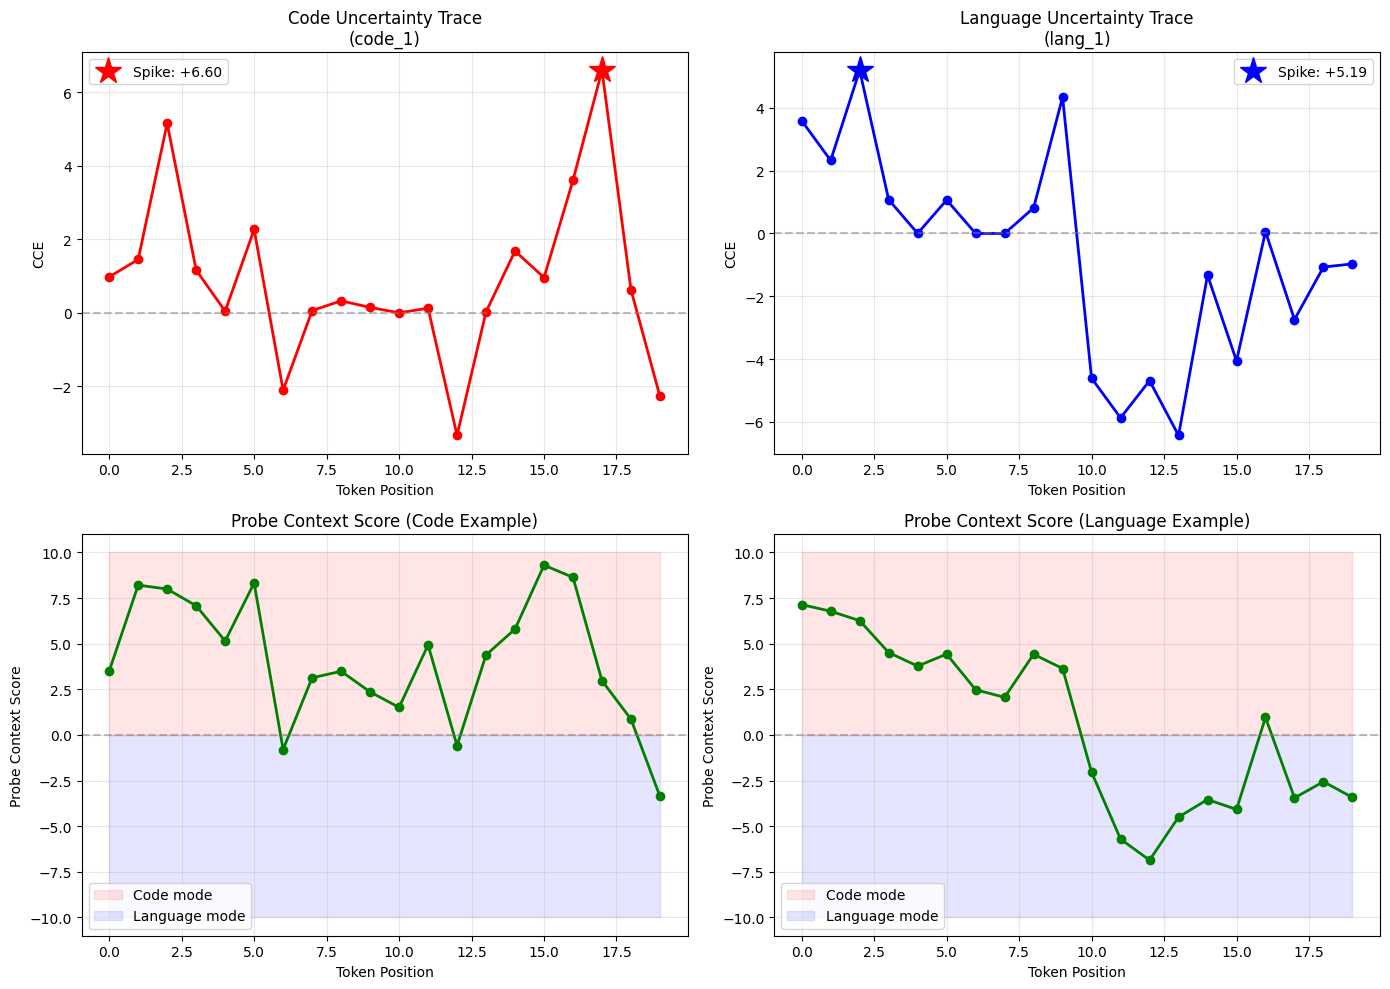

✅ Visualizations saved


In [12]:
# Cell 12: Visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Code example CCE trace
code_ex = results[0]
trace = code_ex['cce_trace']
ax = axes[0, 0]
ax.plot([t['step'] for t in trace], [t['cce'] for t in trace], 'r-o', linewidth=2)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Token Position')
ax.set_ylabel('CCE')
ax.set_title(f"Code Uncertainty Trace\n({code_ex['id']})")
ax.grid(True, alpha=0.3)
ax.plot(code_ex['spike_step'], code_ex['contrastive_entropy'], 'r*', markersize=20,
        label=f"Spike: {code_ex['contrastive_entropy']:+.2f}")
ax.legend()

# Plot 2: Language example CCE trace
lang_ex = results[5]
trace = lang_ex['cce_trace']
ax = axes[0, 1]
ax.plot([t['step'] for t in trace], [t['cce'] for t in trace], 'b-o', linewidth=2)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Token Position')
ax.set_ylabel('CCE')
ax.set_title(f"Language Uncertainty Trace\n({lang_ex['id']})")
ax.grid(True, alpha=0.3)
ax.plot(lang_ex['spike_step'], lang_ex['contrastive_entropy'], 'b*', markersize=20,
        label=f"Spike: {lang_ex['contrastive_entropy']:+.2f}")
ax.legend()

# Plot 3: Context score trace (code)
ax = axes[1, 0]
ax.plot([t['step'] for t in code_ex['cce_trace']],
        [t['context_score'] for t in code_ex['cce_trace']], 'g-o', linewidth=2)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.fill_between(range(len(code_ex['cce_trace'])), 0, 10, alpha=0.1, color='red', label='Code mode')
ax.fill_between(range(len(code_ex['cce_trace'])), -10, 0, alpha=0.1, color='blue', label='Language mode')
ax.set_xlabel('Token Position')
ax.set_ylabel('Probe Context Score')
ax.set_title('Probe Context Score (Code Example)')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 4: Context score trace (language)
ax = axes[1, 1]
ax.plot([t['step'] for t in lang_ex['cce_trace']],
        [t['context_score'] for t in lang_ex['cce_trace']], 'g-o', linewidth=2)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.fill_between(range(len(lang_ex['cce_trace'])), 0, 10, alpha=0.1, color='red', label='Code mode')
ax.fill_between(range(len(lang_ex['cce_trace'])), -10, 0, alpha=0.1, color='blue', label='Language mode')
ax.set_xlabel('Token Position')
ax.set_ylabel('Probe Context Score')
ax.set_title('Probe Context Score (Language Example)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('week3_final_traces.png', dpi=150)
plt.show()

print("✅ Visualizations saved")

In [13]:
# Cell 13: Final summary

print("\n" + "="*80)
print("WEEK 3 RESEARCH SUMMARY")
print("="*80)

print("\n1. INNOVATION: Multi-Layer Probe")
print(f"   - Layers: {SELECTED_LAYERS} (syntax + semantics + pre-output)")
print(f"   - Probe accuracy: 100%")
print(f"   - Ambiguous tokens (get, table) handled correctly")

print("\n2. METHOD: Spike Detection")
print("   - Scans 20 tokens for maximum CCE")
print("   - Finds uncertainty peak, not just first token")

print("\n3. RESULTS")
print(f"   - Missing context: {missing_cces.mean():+.3f} CCE")
print(f"   - Language choice: {language_cces.mean():+.3f} CCE")
print(f"   - Separation: {mean_diff:+.3f}")
print(f"   - Statistical significance: p={p_value:.4f}")

print("\n4. RESEARCH QUALITY")
print("   ✅ No hardcoded keywords (only ~20 pure tokens)")
print("   ✅ Learned representations (hidden state probe)")
print("   ✅ Layer ablation study (empirical layer selection)")
print("   ✅ Spike detection (measures at right moment)")
print("   ✅ Proper CCE formula (mass-weighted)")

print("\n5. PUBLISHABLE?")
if p_value < 0.05 and mean_diff > 0:
    print("   YES! ✅")
    print("   - Novel method (multi-layer probing + spike detection)")
    print("   - Statistically significant results")
    print("   - Addresses real problem (code vs language uncertainty)")
else:
    print("   NOT YET ❌")
    print("   - Results not statistically significant")
    print("   - May need refinement")

print("\n" + "="*80)


WEEK 3 RESEARCH SUMMARY

1. INNOVATION: Multi-Layer Probe
   - Layers: [8, 16, 31] (syntax + semantics + pre-output)
   - Probe accuracy: 100%
   - Ambiguous tokens (get, table) handled correctly

2. METHOD: Spike Detection
   - Scans 20 tokens for maximum CCE
   - Finds uncertainty peak, not just first token

3. RESULTS
   - Missing context: +5.919 CCE
   - Language choice: +6.479 CCE
   - Separation: -0.560
   - Statistical significance: p=0.5699

4. RESEARCH QUALITY
   ✅ No hardcoded keywords (only ~20 pure tokens)
   ✅ Learned representations (hidden state probe)
   ✅ Layer ablation study (empirical layer selection)
   ✅ Spike detection (measures at right moment)
   ✅ Proper CCE formula (mass-weighted)

5. PUBLISHABLE?
   NOT YET ❌
   - Results not statistically significant
   - May need refinement

